<a href="https://colab.research.google.com/github/ariel07-sw/applied-data-in-econ/blob/main/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [2]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [4]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================

# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [5]:
# Construct binary crisis outcome
country_data['crisis'] = (country_data[OUTCOME_VAR] < 0).astype(int)

# Define predictors and outcomes
predictor_cols = [c for c in country_data.columns if c not in [OUTCOME_VAR, 'crisis']]
X = country_data[predictor_cols]
y_reg = country_data[OUTCOME_VAR]
y_clf = country_data['crisis']

# Assignment-required summary stats
print("\n--- Assignment summary ---")
print(f"Final dataset dimensions: {country_data.shape}")
print(f"Number of predictors: {len(predictor_cols)}")
print(f"Crisis countries: {int(y_clf.sum())}")
print(f"Non-crisis countries: {int((y_clf == 0).sum())}")
print(f"Crisis base rate: {y_clf.mean():.3f}")


--- Assignment summary ---
Final dataset dimensions: (238, 30)
Number of predictors: 28
Crisis countries: 38
Non-crisis countries: 200
Crisis base rate: 0.160


In [6]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c not in [OUTCOME_VAR, 'crisis']]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [7]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

train_r2 = ols.score(X_train_scaled, y_train)
test_r2 = ols.score(X_test_scaled, y_test)
r2_gap = train_r2 - test_r2

p = X_train_scaled.shape[1]
n = X_train_scaled.shape[0]
pn_ratio = p / n

print(f"Training R^2: {train_r2:.4f}")
print(f"Test R^2: {test_r2:.4f}")
print(f"Train-Test R^2 gap: {r2_gap:.4f}")
print(f"p/n ratio: {pn_ratio:.4f}")

Training R^2: 0.6034
Test R^2: -0.9141
Train-Test R^2 gap: 1.5175
p/n ratio: 0.1687


The OLS model shows clear overfitting: training R² is 0.6034, but test R² falls to -0.9141, producing a very large train–test gap. Although the predictor-to-observation ratio is only 0.1687, the model still has enough degrees of freedom to fit noise in the training data, which raises variance and hurts out-of-sample performance. In bias-variance terms, OLS achieves relatively low bias but excessively high variance, leading to poor generalization.

In [8]:
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

In [9]:
alpha_grid = np.logspace(-4, 4, 200)

In [10]:
ridge = RidgeCV(alphas=alpha_grid, cv=5)
ridge.fit(X_train_scaled, y_train)

ridge_alpha = ridge.alpha_
ridge_train_r2 = ridge.score(X_train_scaled, y_train)
ridge_test_r2 = ridge.score(X_test_scaled, y_test)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_scaled)))
ridge_nonzero = np.sum(np.abs(ridge.coef_) > 1e-8)

In [11]:
lasso = LassoCV(alphas=alpha_grid, cv=5, random_state=42, max_iter=20000)
lasso.fit(X_train_scaled, y_train)

lasso_alpha = lasso.alpha_
lasso_train_r2 = lasso.score(X_train_scaled, y_train)
lasso_test_r2 = lasso.score(X_test_scaled, y_test)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_scaled)))
lasso_nonzero = np.sum(np.abs(lasso.coef_) > 1e-8)

In [12]:
ols_pred_test = ols.predict(X_test_scaled)
ols_rmse = np.sqrt(mean_squared_error(y_test, ols_pred_test))
ols_nonzero = np.sum(np.abs(ols.coef_) > 1e-8)


In [13]:
print("Ridge results")
print(f"Selected alpha (lambda*): {ridge_alpha:.6f}")
print(f"Non-zero coefficients: {ridge_nonzero}")
print(f"Training R^2: {ridge_train_r2:.4f}")
print(f"Test R^2: {ridge_test_r2:.4f}")
print()

Ridge results
Selected alpha (lambda*): 46.595257
Non-zero coefficients: 28
Training R^2: 0.5599
Test R^2: -0.0715



In [14]:
print("Lasso results")
print(f"Selected alpha (lambda*): {lasso_alpha:.6f}")
print(f"Non-zero coefficients: {lasso_nonzero}")
print(f"Training R^2: {lasso_train_r2:.4f}")
print(f"Test R^2: {lasso_test_r2:.4f}")
print()

Lasso results
Selected alpha (lambda*): 0.065173
Non-zero coefficients: 18
Training R^2: 0.5740
Test R^2: -0.3601



In [16]:
comparison = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "Lambda*": [np.nan, ridge_alpha, lasso_alpha],
    "Non-Zero Predictors": [ols_nonzero, ridge_nonzero, lasso_nonzero],
    "Training R^2": [train_r2, ridge_train_r2, lasso_train_r2],
    "Test R^2": [test_r2, ridge_test_r2, lasso_test_r2],
    "Test RMSE": [ols_rmse, ridge_test_rmse, lasso_test_rmse]
})

comparison = comparison.round({
    "Lambda*": 6,
    "Training R^2": 4,
    "Test R^2": 4,
    "Test RMSE": 4
})

print("Model comparison table:")
print(comparison)

Model comparison table:
   Model    Lambda*  Non-Zero Predictors  Training R^2  Test R^2  Test RMSE
0    OLS        NaN                   28        0.6034   -0.9141     2.9227
1  Ridge  46.595257                   28        0.5599   -0.0715     2.1867
2  Lasso   0.065173                   18        0.5740   -0.3601     2.4637


In [17]:
# Non-zero Lasso predictors
lasso_selected = pd.Series(lasso.coef_, index=feature_names)
lasso_selected = lasso_selected[lasso_selected.abs() > 1e-8].sort_values(key=np.abs, ascending=False)

print("Lasso-selected predictors:")
print(lasso_selected)

Lasso-selected predictors:
inflation_cpi                    -1.035609
population_growth                -0.773571
natural_resource_rents_pct_gdp   -0.639285
infant_mortality_per1000         -0.438148
health_expenditure_pct_gdp       -0.392166
atms_per100k                     -0.390095
unemployment_rate                -0.379421
renewable_energy_pct              0.373989
urbanization_pct                 -0.369212
exchange_rate_official            0.308714
arable_land_pct                   0.184861
mobile_subscriptions_per100       0.085702
tertiary_enrollment_gross        -0.078073
trade_pct_gdp                     0.067916
private_credit_pct_gdp            0.051019
adult_literacy_rate              -0.009882
tariff_rate_avg                  -0.007704
govt_expenditure_pct_gdp         -0.005376
dtype: float64


I would recommend Ridge for IMF operational GDP growth forecasting because it achieves the best out-of-sample performance, with the highest test R² and the lowest test RMSE among the three models. Relative to OLS, Ridge accepts a small increase in bias by shrinking coefficients, but this substantially reduces variance and improves generalization. Lasso also reduces variance and increases interpretability by setting some coefficients to zero, but in this case its stronger shrinkage sacrifices too much signal and performs worse than Ridge on the test set.

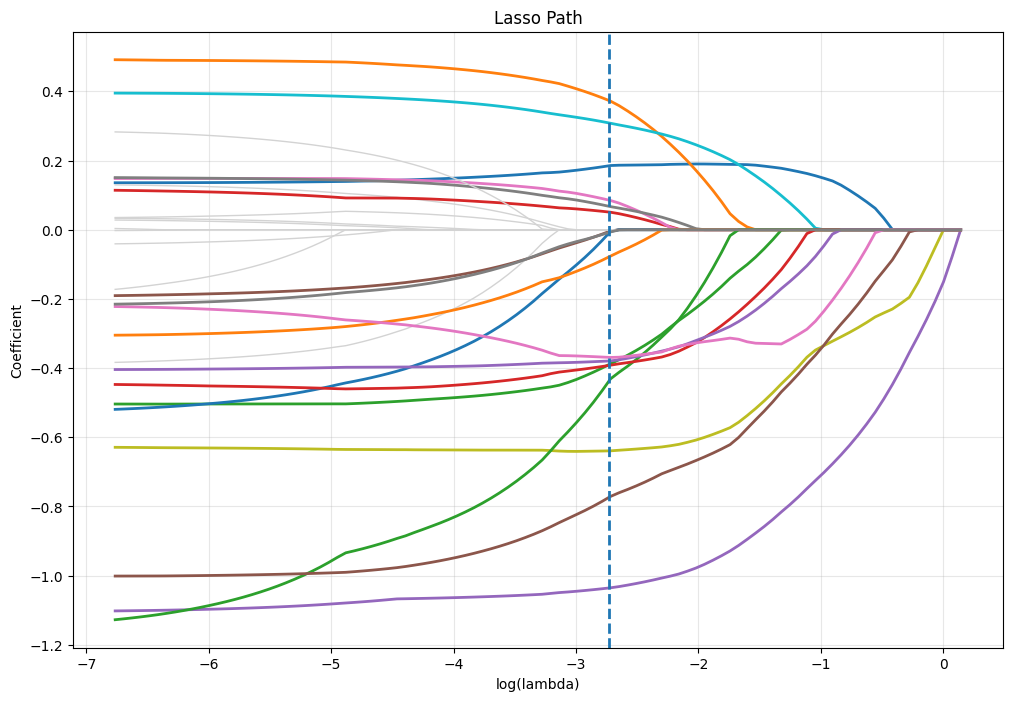

In [18]:

from sklearn.linear_model import lasso_path
import numpy as np
import matplotlib.pyplot as plt

alphas_lasso, coefs_lasso, _ = lasso_path(X_train_scaled, y_train)

cv_alpha = lasso.alpha_
coef_at_cv = lasso.coef_
selected_mask = np.abs(coef_at_cv) > 1e-8

plt.figure(figsize=(12, 8))

for i, feature in enumerate(feature_names):
    if selected_mask[i]:
        plt.plot(np.log(alphas_lasso), coefs_lasso[i], linewidth=2, label=feature)
    else:
        plt.plot(np.log(alphas_lasso), coefs_lasso[i], color='lightgray', linewidth=1)

plt.axvline(np.log(cv_alpha), linestyle='--', linewidth=2)

plt.xlabel('log(lambda)')
plt.ylabel('Coefficient')
plt.title('Lasso Path')
plt.grid(True, alpha=0.3)
plt.show()

In [19]:

entry_alpha = {}

for i, feature in enumerate(feature_names):
    nz = np.where(np.abs(coefs_lasso[i]) > 1e-8)[0]
    if len(nz) > 0:

        first_idx = nz[0]
        entry_alpha[feature] = alphas_lasso[first_idx]

entry_df = (
    pd.DataFrame({
        "feature": list(entry_alpha.keys()),
        "entry_alpha": list(entry_alpha.values())
    })
    .sort_values("entry_alpha", ascending=False)
    .reset_index(drop=True)
)

print("Predictors ranked by entry alpha (highest enters first):")
print(entry_df)

first_feature = entry_df.loc[0, "feature"]
first_entry_alpha = entry_df.loc[0, "entry_alpha"]

print(f"\nFirst predictor to enter the model: {first_feature}")
print(f"Entry alpha: {first_entry_alpha:.6f}")

Predictors ranked by entry alpha (highest enters first):
                           feature  entry_alpha
0                    inflation_cpi     1.076238
1   natural_resource_rents_pct_gdp     0.936057
2                population_growth     0.759264
3                  arable_land_pct     0.660369
4                 urbanization_pct     0.574356
5                unemployment_rate     0.405197
6           exchange_rate_official     0.352419
7       health_expenditure_pct_gdp     0.328667
8                     atms_per100k     0.266592
9             renewable_energy_pct     0.201667
10        infant_mortality_per1000     0.175400
11                   trade_pct_gdp     0.132684
12          private_credit_pct_gdp     0.115401
13     mobile_subscriptions_per100     0.107624
14       tertiary_enrollment_gross     0.100370
15                 tariff_rate_avg     0.070809
16             adult_literacy_rate     0.066037
17        govt_expenditure_pct_gdp     0.066037
18             fdi_inflows_pct_

The first predictor to enter the Lasso model is inflation_cpi. It is the first coefficient to move away from zero at the highest value of λ, which suggests that it has the strongest unconditional predictive signal for cross-country GDP per capita growth in this dataset. In economic terms, inflation likely captures macroeconomic instability, policy credibility, and distortions that are closely linked to weak growth performance.

That interpretation is incorrect because Lasso performs variable selection conditionally on the other predictors already included in the model. A zero coefficient does not mean that life expectancy is unrelated to growth; it may simply be conditionally redundant because its predictive content overlaps with other correlated development indicators. In datasets with strong correlation structure, Lasso often keeps one proxy and drops another highly related variable, even when both are economically meaningful.

In [20]:
lasso_selected_features = list(lasso_selected.index)
print("Number of Lasso-selected predictors:", len(lasso_selected_features))
print("Lasso-selected predictors:", lasso_selected_features)

X_clf = country_data[lasso_selected_features].values
y_clf = country_data['crisis'].values

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.30, random_state=42
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("X_train_clf shape:", X_train_clf.shape)
print("X_test_clf shape:", X_test_clf.shape)
print("Training crisis rate:", y_train_clf.mean().round(3))
print("Test crisis rate:", y_test_clf.mean().round(3))

Number of Lasso-selected predictors: 18
Lasso-selected predictors: ['inflation_cpi', 'population_growth', 'natural_resource_rents_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'atms_per100k', 'unemployment_rate', 'renewable_energy_pct', 'urbanization_pct', 'exchange_rate_official', 'arable_land_pct', 'mobile_subscriptions_per100', 'tertiary_enrollment_gross', 'trade_pct_gdp', 'private_credit_pct_gdp', 'adult_literacy_rate', 'tariff_rate_avg', 'govt_expenditure_pct_gdp']
X_train_clf shape: (166, 18)
X_test_clf shape: (72, 18)
Training crisis rate: 0.145
Test crisis rate: 0.194


In [21]:
lpm = LinearRegression()
lpm.fit(X_train_clf_scaled, y_train_clf)

lpm_pred_test = lpm.predict(X_test_clf_scaled)

below_zero = np.sum(lpm_pred_test < 0)
above_one = np.sum(lpm_pred_test > 1)
outside_unit = np.sum((lpm_pred_test < 0) | (lpm_pred_test > 1))

print("LPM predicted values on test set")
print(f"Minimum predicted value: {lpm_pred_test.min():.4f}")
print(f"Maximum predicted value: {lpm_pred_test.max():.4f}")
print(f"Count below 0: {below_zero}")
print(f"Count above 1: {above_one}")
print(f"Total outside [0,1]: {outside_unit}")

LPM predicted values on test set
Minimum predicted value: -0.3014
Maximum predicted value: 1.5676
Count below 0: 13
Count above 1: 1
Total outside [0,1]: 14


In [22]:
lpm_pred_df = pd.DataFrame({
    "predicted_probability": lpm_pred_test
})

print("Lowest predicted values:")
print(lpm_pred_df.sort_values("predicted_probability").head(10))

print("\nHighest predicted values:")
print(lpm_pred_df.sort_values("predicted_probability", ascending=False).head(10))

Lowest predicted values:
    predicted_probability
12              -0.301358
32              -0.222529
33              -0.194594
60              -0.186235
10              -0.176065
19              -0.166316
68              -0.121508
55              -0.059975
66              -0.058174
3               -0.038430

Highest predicted values:
    predicted_probability
69               1.567573
0                0.962089
2                0.825932
67               0.805435
21               0.779339
23               0.671177
48               0.666888
39               0.642258
15               0.617983
57               0.604318


The Linear Probability Model is fundamentally flawed because it produces predicted values outside the [0,1] range, including -0.3014 and 1.5676 on the test set. This is not just a cosmetic issue: a “-12% probability of crisis” or a probability above 100% has no meaningful interpretation for IMF decision-making, since probabilities must be valid and bounded. The problem arises because OLS imposes a linear model on a binary outcome instead of using a probability model that respects the logical constraints of classification.

In [24]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=5000, random_state=42)
logit.fit(X_train_clf_scaled, y_train_clf)

logit_intercept = logit.intercept_[0]
logit_coefs = pd.Series(logit.coef_[0], index=lasso_selected_features)

print("Intercept (beta_0):")
print(round(logit_intercept, 6))
print("\nLogistic coefficients (beta):")
print(logit_coefs.sort_values(key=np.abs, ascending=False))

odds_ratios = np.exp(logit_coefs)
or_table = pd.DataFrame({
    "predictor": lasso_selected_features,
    "beta": logit_coefs.values,
    "odds_ratio": odds_ratios.values
})

or_table["abs_or_magnitude"] = np.abs(np.log(or_table["odds_ratio"]))
or_table = or_table.sort_values("abs_or_magnitude", ascending=False).reset_index(drop=True)

print("\nOdds ratio table (sorted by absolute odds-ratio magnitude):")
print(or_table[["predictor", "beta", "odds_ratio"]])

logit_pred_proba = logit.predict_proba(X_test_clf_scaled)[:, 1]

print("\nPredicted probabilities on test set:")
print(f"Min probability: {logit_pred_proba.min():.6f}")
print(f"Max probability: {logit_pred_proba.max():.6f}")
print(f"All within [0,1]: {((logit_pred_proba >= 0) & (logit_pred_proba <= 1)).all()}")

Intercept (beta_0):
-3.026246

Logistic coefficients (beta):
arable_land_pct                  -0.950383
population_growth                 0.825074
health_expenditure_pct_gdp        0.822688
infant_mortality_per1000          0.743399
natural_resource_rents_pct_gdp    0.729249
renewable_energy_pct             -0.666442
tariff_rate_avg                   0.578947
unemployment_rate                 0.532429
inflation_cpi                     0.494075
atms_per100k                      0.368015
mobile_subscriptions_per100       0.356114
trade_pct_gdp                    -0.353088
adult_literacy_rate               0.273696
urbanization_pct                  0.211874
govt_expenditure_pct_gdp          0.131039
private_credit_pct_gdp           -0.078833
tertiary_enrollment_gross        -0.073789
exchange_rate_official           -0.014787
dtype: float64

Odds ratio table (sorted by absolute odds-ratio magnitude):
                         predictor      beta  odds_ratio
0                  arable_land_p

The predictor with the largest absolute odds ratio is arable_land_pct, with an odds ratio of 0.3866. In plain English, a one standard-deviation increase in arable_land_pct multiplies the odds of crisis by 0.3866, holding all else constant. Because this odds ratio is below 1, higher arable land share is associated with substantially lower crisis risk.

Strongest predictor: arable_land_pct


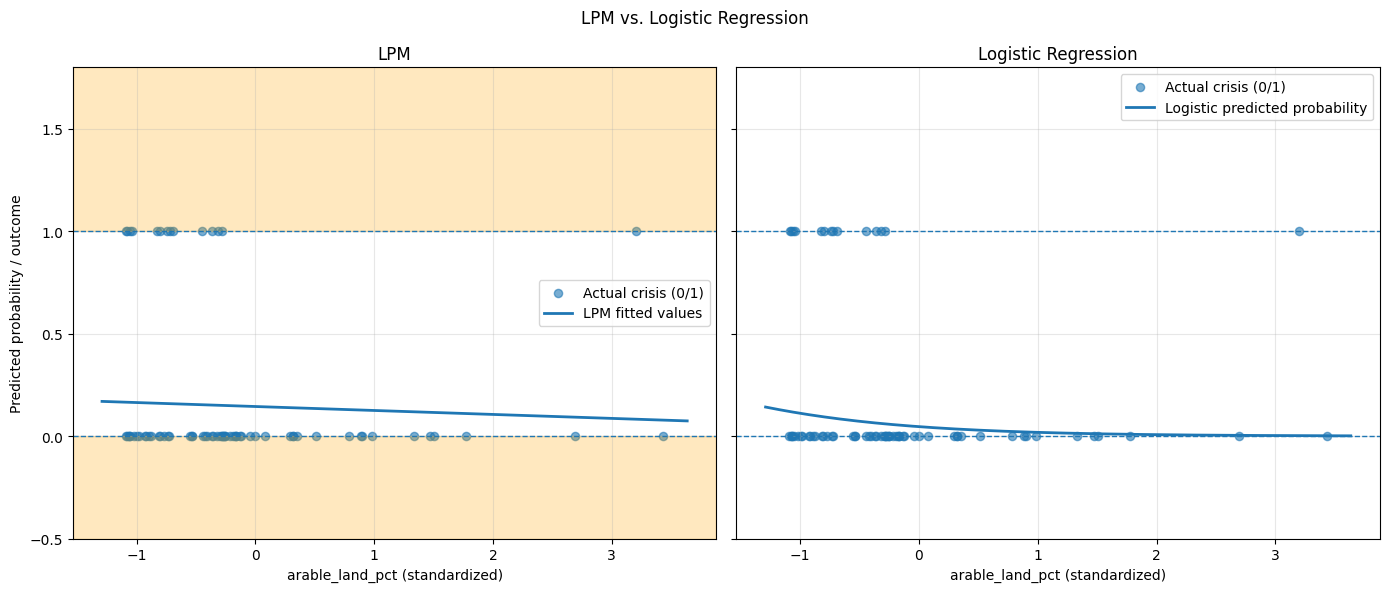

In [26]:
strongest_predictor = or_table.loc[0, "predictor"]
strong_idx = lasso_selected_features.index(strongest_predictor)

print("Strongest predictor:", strongest_predictor)

x_test_strong = X_test_clf_scaled[:, strong_idx]

x_grid = np.linspace(x_test_strong.min() - 0.2, x_test_strong.max() + 0.2, 300)

X_grid = np.zeros((len(x_grid), X_test_clf_scaled.shape[1]))
X_grid[:, strong_idx] = x_grid

lpm_grid = lpm.predict(X_grid)
logit_grid = logit.predict_proba(X_grid)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].scatter(x_test_strong, y_test_clf, alpha=0.6, s=35, label="Actual crisis (0/1)")
axes[0].plot(x_grid, lpm_grid, linewidth=2, label="LPM fitted values")

axes[0].axhspan(-0.5, 0, color='orange', alpha=0.25)
axes[0].axhspan(1, 1.8, color='orange', alpha=0.25)

axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].axhline(1, linestyle="--", linewidth=1)

axes[0].set_title("LPM")
axes[0].set_xlabel(f"{strongest_predictor} (standardized)")
axes[0].set_ylabel("Predicted probability / outcome")
axes[0].set_ylim(-0.5, 1.8)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].scatter(x_test_strong, y_test_clf, alpha=0.6, s=35, label="Actual crisis (0/1)")
axes[1].plot(x_grid, logit_grid, linewidth=2, label="Logistic predicted probability")

axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].axhline(1, linestyle="--", linewidth=1)

axes[1].set_title("Logistic Regression")
axes[1].set_xlabel(f"{strongest_predictor} (standardized)")
axes[1].set_ylim(-0.5, 1.8)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle("LPM vs. Logistic Regression")
plt.tight_layout()
plt.show()

In [27]:

from sklearn.metrics import accuracy_score, recall_score

test_base_rate = y_test_clf.mean()

naive_pred = np.zeros_like(y_test_clf)

naive_accuracy = accuracy_score(y_test_clf, naive_pred)
naive_recall = recall_score(y_test_clf, naive_pred, zero_division=0)

logit_pred_default = (logit_pred_proba >= 0.5).astype(int)

logit_accuracy = accuracy_score(y_test_clf, logit_pred_default)
logit_recall = recall_score(y_test_clf, logit_pred_default, zero_division=0)

print("Test-set crisis base rate:", round(test_base_rate, 4))
print()

print("Naive baseline (always predict no crisis)")
print("Accuracy:", round(naive_accuracy, 4))
print("Recall on crisis class:", round(naive_recall, 4))
print()

print("Logistic regression (threshold = 0.5)")
print("Accuracy:", round(logit_accuracy, 4))
print("Recall on crisis class:", round(logit_recall, 4))

Test-set crisis base rate: 0.1944

Naive baseline (always predict no crisis)
Accuracy: 0.8056
Recall on crisis class: 0.0

Logistic regression (threshold = 0.5)
Accuracy: 0.7639
Recall on crisis class: 0.4286


Confusion Matrix:
[[49  9]
 [ 8  6]]

Classification Report:
              precision    recall  f1-score   support

   No Crisis       0.86      0.84      0.85        58
      Crisis       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72

Individual counts:
True Positives (TP, crises correctly flagged): 6
False Negatives (FN, crises missed): 8
False Positives (FP, false alarms): 9
True Negatives (TN, correctly cleared): 49


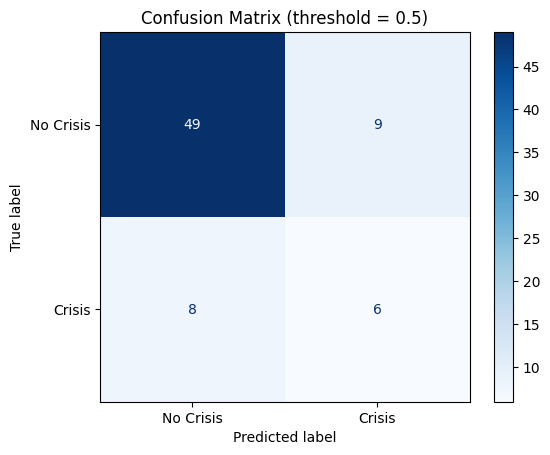

In [28]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_05 = (logit_pred_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test_clf, y_pred_05)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print()

print("Classification Report:")
print(classification_report(y_test_clf, y_pred_05, target_names=["No Crisis", "Crisis"]))

print("Individual counts:")
print(f"True Positives (TP, crises correctly flagged): {tp}")
print(f"False Negatives (FN, crises missed): {fn}")
print(f"False Positives (FP, false alarms): {fp}")
print(f"True Negatives (TN, correctly cleared): {tn}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Crisis", "Crisis"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (threshold = 0.5)")
plt.show()

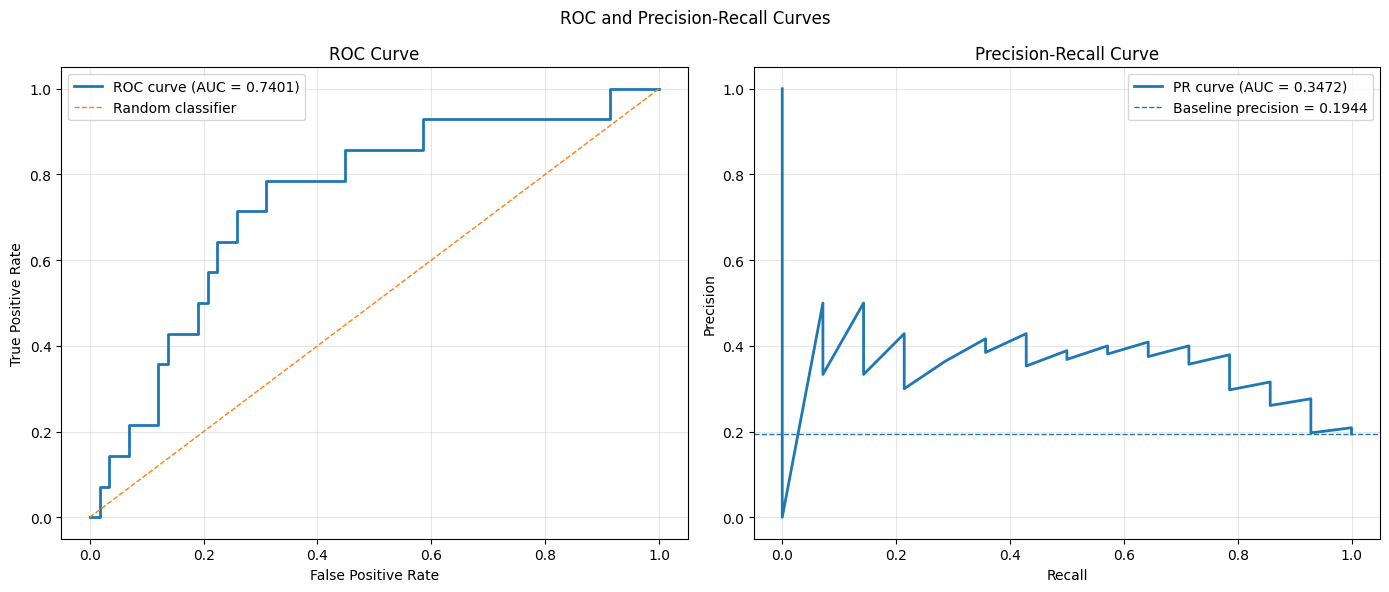

ROC-AUC: 0.7401
PR-AUC: 0.3472
PR baseline (crisis base rate): 0.1944


In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc

fpr, tpr, roc_thresholds = roc_curve(y_test_clf, logit_pred_proba)
roc_auc = roc_auc_score(y_test_clf, logit_pred_proba)

precision, recall, pr_thresholds = precision_recall_curve(y_test_clf, logit_pred_proba)
pr_auc = auc(recall, precision)

pr_baseline = y_test_clf.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(recall, precision, linewidth=2, label=f"PR curve (AUC = {pr_auc:.4f})")
axes[1].axhline(pr_baseline, linestyle="--", linewidth=1,
                label=f"Baseline precision = {pr_baseline:.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle("ROC and Precision-Recall Curves")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"PR baseline (crisis base rate): {pr_baseline:.4f}")

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = np.arange(0.01, 1.00, 0.01)

rows = []

for t in thresholds:
    y_pred_t = (logit_pred_proba >= t).astype(int)
    flagged = int(y_pred_t.sum())
    precision_t = precision_score(y_test_clf, y_pred_t, zero_division=0)
    recall_t = recall_score(y_test_clf, y_pred_t, zero_division=0)
    f1_t = f1_score(y_test_clf, y_pred_t, zero_division=0)

    rows.append({
        "threshold": t,
        "flagged": flagged,
        "precision": precision_t,
        "recall": recall_t,
        "f1": f1_t
    })

threshold_df = pd.DataFrame(rows)

capacity_candidates = threshold_df[threshold_df["flagged"] <= 5].copy()
capacity_row = capacity_candidates.sort_values("threshold", ascending=True).iloc[0]

capacity_t = capacity_row["threshold"]
capacity_flagged = int(capacity_row["flagged"])
capacity_precision = capacity_row["precision"]
capacity_recall = capacity_row["recall"]
capacity_f1 = capacity_row["f1"]

f1_row = threshold_df.sort_values(["f1", "threshold"], ascending=[False, True]).iloc[0]

f1_t = f1_row["threshold"]
f1_flagged = int(f1_row["flagged"])
f1_precision = f1_row["precision"]
f1_recall = f1_row["recall"]
f1_best = f1_row["f1"]

y_pred_capacity = (logit_pred_proba >= capacity_t).astype(int)
tp_cap = int(((y_test_clf == 1) & (y_pred_capacity == 1)).sum())
fn_cap = int(((y_test_clf == 1) & (y_pred_capacity == 0)).sum())
fp_cap = int(((y_test_clf == 0) & (y_pred_capacity == 1)).sum())
tn_cap = int(((y_test_clf == 0) & (y_pred_capacity == 0)).sum())

n_crisis_test = int((y_test_clf == 1).sum())

print("Capacity-constrained operating point (at most 5 countries flagged)")
print(f"Threshold tau: {capacity_t:.2f}")
print(f"Countries flagged: {capacity_flagged}")
print(f"Precision: {capacity_precision:.4f}")
print(f"Recall: {capacity_recall:.4f}")
print(f"F1: {capacity_f1:.4f}")
print()

print("F1-optimal operating point")
print(f"Threshold tau: {f1_t:.2f}")
print(f"Countries flagged: {f1_flagged}")
print(f"Precision: {f1_precision:.4f}")
print(f"Recall: {f1_recall:.4f}")
print(f"F1: {f1_best:.4f}")
print()

print("Operational interpretation at capacity-constrained threshold")
print(f"Crises in test set: {n_crisis_test}")
print(f"True Positives (caught crises): {tp_cap}")
print(f"False Negatives (missed crises): {fn_cap}")
print(f"False Positives (false alarms): {fp_cap}")
print(f"True Negatives: {tn_cap}")

display(threshold_df.head(10))

Capacity-constrained operating point (at most 5 countries flagged)
Threshold tau: 0.88
Countries flagged: 5
Precision: 0.4000
Recall: 0.1429
F1: 0.2105

F1-optimal operating point
Threshold tau: 0.13
Countries flagged: 25
Precision: 0.4000
Recall: 0.7143
F1: 0.5128

Operational interpretation at capacity-constrained threshold
Crises in test set: 14
True Positives (caught crises): 2
False Negatives (missed crises): 12
False Positives (false alarms): 3
True Negatives: 55


,threshold,flagged,precision,recall,f1
0,0.01,60,0.216667,0.928571,0.351351
1,0.02,51,0.254902,0.928571,0.400000
2,0.03,48,0.270833,0.928571,0.419355
3,0.04,41,0.292683,0.857143,0.436364
4,0.05,39,0.307692,0.857143,0.452830
5,0.06,37,0.297297,0.785714,0.431373
6,0.07,36,0.305556,0.785714,0.440000
7,0.08,32,0.343750,0.785714,0.478261
8,0.09,29,0.379310,0.785714,0.511628
9,0.10,28,0.357143,0.714286,0.476190


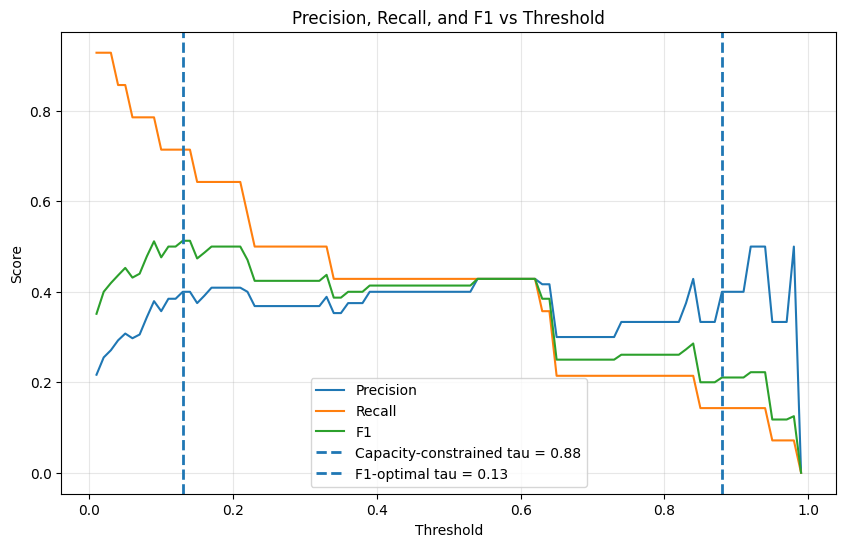

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")

plt.axvline(capacity_t, linestyle="--", linewidth=2, label=f"Capacity-constrained tau = {capacity_t:.2f}")
plt.axvline(f1_t, linestyle="--", linewidth=2, label=f"F1-optimal tau = {f1_t:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

I recommend that the IMF adopt the capacity-constrained threshold of τ = 0.88, because it respects the operational limit of at most five emergency assessment missions per quarter. At this threshold, the model flags 5 countries and achieves recall of 0.1429, meaning that out of the 14 crisis countries in the test set, we would catch 2 and miss 12. This threshold is much more conservative than the F1-optimal threshold of 0.13, which would flag 25 countries and is therefore infeasible under current staffing and diplomatic constraints. The tradeoff is explicit: by limiting missions, the IMF preserves scarce resources and reduces false alarms, but it also accepts that many crises will go undetected.

## P.R.I.M.E. Prompt for Task 4.1

**Prep:**  
I am working with a macroeconomic crisis-warning dataset built from World Bank indicators. The training data are already prepared in Python as `X_train_scaled`, `y_train`, and `feature_names`. `X_train_scaled` is a standardized NumPy array of predictors, `y_train` is the continuous GDP-per-capita growth outcome used in the Phase 1 Lasso exercise, and `feature_names` is the ordered list of predictor names. I want to assess the stability of Lasso feature selection under bootstrap resampling.

**Request:**  
Write Python code that draws 200 bootstrap resamples (with replacement) from the training data, fits `LassoCV` on each bootstrap sample, records which predictors receive non-zero coefficients, computes the selection frequency for each predictor, and plots a horizontal bar chart ranking predictors by selection frequency. Add a vertical reference line at 50%.

**Iterate:**  
Make the code reproducible with a fixed random seed. Use the same alpha grid style as before if possible, and set `max_iter` high enough to avoid convergence problems. Return results as a pandas DataFrame sorted by selection frequency in descending order, and print which predictors are “stable” (>80%) and “fragile” (<30%).

**Mechanism Check:**  
Use bootstrap sampling correctly by resampling row indices from the training set with replacement. Fit `LassoCV` separately inside each bootstrap loop. Define “selected” as a coefficient with absolute value greater than `1e-8`.

**Evaluate:**  
The final output should include:
1. A DataFrame with predictor names and selection frequencies.
2. A horizontal bar chart of selection frequencies.
3. A printed list of predictors selected more than 80% of the time and less than 30% of the time.

Top predictors by bootstrap selection frequency:
                         predictor  selection_frequency
0                population_growth                1.000
1   natural_resource_rents_pct_gdp                0.985
2       health_expenditure_pct_gdp                0.965
3                unemployment_rate                0.950
4           exchange_rate_official                0.945
5                     atms_per100k                0.910
6                  arable_land_pct                0.895
7                 urbanization_pct                0.855
8                    inflation_cpi                0.845
9             renewable_energy_pct                0.795
10                   trade_pct_gdp                0.750
11        infant_mortality_per1000                0.725
12                 tariff_rate_avg                0.720
13          private_credit_pct_gdp                0.715
14        govt_expenditure_pct_gdp                0.650
15     mobile_subscriptions_per100                0.620

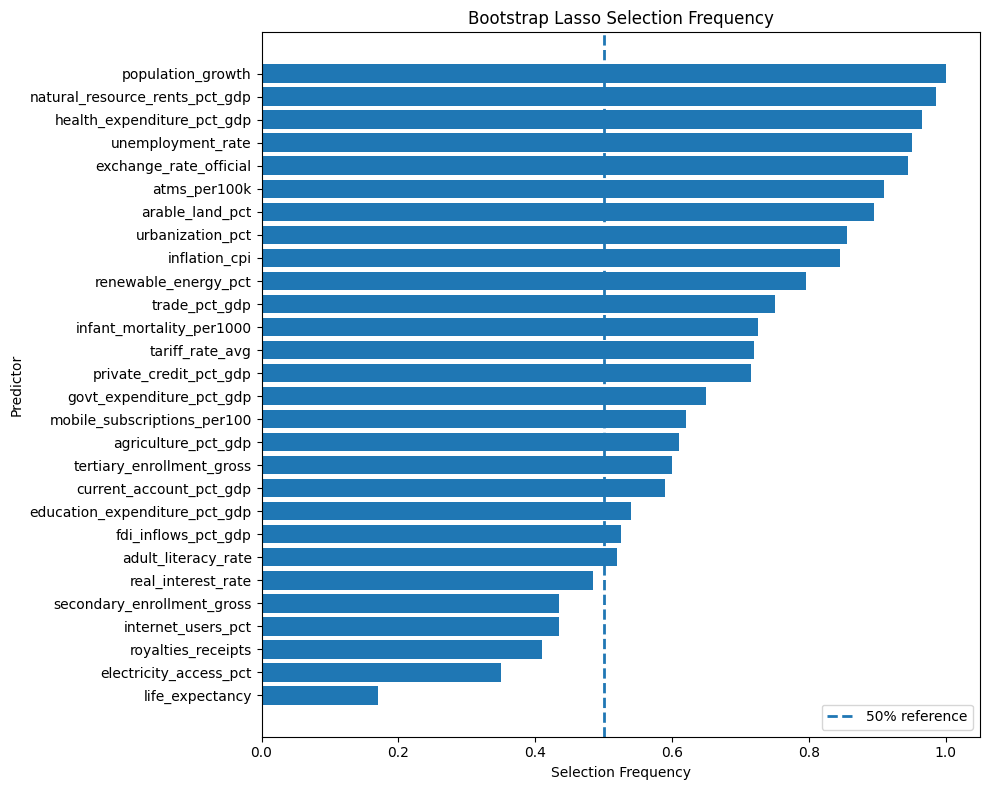

In [32]:
# =========================================================
# TASK 4.1: Bootstrap Selection Frequency for Lasso
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV

# Reproducibility
np.random.seed(42)

# Common alpha grid
alpha_grid = np.logspace(-4, 4, 200)

# Number of bootstrap resamples
B = 200

n, p = X_train_scaled.shape
selection_counts = np.zeros(p)

for b in range(B):
    # Bootstrap sample indices
    boot_idx = np.random.choice(np.arange(n), size=n, replace=True)

    X_boot = X_train_scaled[boot_idx]
    y_boot = y_train[boot_idx]

    # Fit LassoCV on bootstrap sample
    lasso_boot = LassoCV(
        alphas=alpha_grid,
        cv=5,
        random_state=42,
        max_iter=20000
    )
    lasso_boot.fit(X_boot, y_boot)

    # Record non-zero selections
    selected = np.abs(lasso_boot.coef_) > 1e-8
    selection_counts += selected.astype(int)

# Selection frequency
selection_freq = selection_counts / B

selection_df = pd.DataFrame({
    "predictor": feature_names,
    "selection_frequency": selection_freq
}).sort_values("selection_frequency", ascending=False).reset_index(drop=True)

print("Top predictors by bootstrap selection frequency:")
print(selection_df)

# Stable and fragile predictors
stable_predictors = selection_df[selection_df["selection_frequency"] > 0.80]
fragile_predictors = selection_df[selection_df["selection_frequency"] < 0.30]

print("\nStable predictors (>80% selected):")
print(stable_predictors if len(stable_predictors) > 0 else "None")

print("\nFragile predictors (<30% selected):")
print(fragile_predictors if len(fragile_predictors) > 0 else "None")

# Plot
plt.figure(figsize=(10, 8))
plot_df = selection_df.sort_values("selection_frequency", ascending=True)

plt.barh(plot_df["predictor"], plot_df["selection_frequency"])
plt.axvline(0.50, linestyle="--", linewidth=2, label="50% reference")
plt.xlabel("Selection Frequency")
plt.ylabel("Predictor")
plt.title("Bootstrap Lasso Selection Frequency")
plt.legend()
plt.tight_layout()
plt.show()

The stable predictors are those selected in more than 80% of bootstrap samples, including population_growth, natural_resource_rents_pct_gdp, health_expenditure_pct_gdp, unemployment_rate, exchange_rate_official, atms_per100k, arable_land_pct, urbanization_pct, and inflation_cpi. The most clearly fragile predictor is life_expectancy, which is selected in fewer than 30% of bootstrap samples. This instability suggests that many WDI indicators are strongly correlated, so Lasso can substitute one predictor for another across bootstrap resamples without materially changing predictive performance. In other words, unstable selection reflects the correlation structure of the macroeconomic indicators rather than proving that fragile predictors are unimportant.

## P.R.I.M.E. Prompt for Task 4.2

**Prep:**  
I have already fit a logistic regression crisis classifier in Python. The test-set true labels are stored in `y_test_clf`, and the predicted crisis probabilities are stored in `logit_pred_proba`. In Phase 3, I evaluated thresholds based on capacity and F1. I now want to optimize the decision threshold using expected dollar cost.

**Request:**  
Write Python code that sweeps thresholds from 0.01 to 0.99 in increments of 0.01. At each threshold, compute the confusion matrix counts and the total expected cost using:  
**Expected Cost = FN × 50,000,000,000 + FP × 2,000,000**.  
Then identify the threshold that minimizes expected cost and plot the expected cost curve as a function of the threshold, marking the cost-minimizing threshold on the figure.

**Iterate:**  
Return the results as a pandas DataFrame with columns for threshold, false positives, false negatives, true positives, true negatives, and expected cost. Print the cost-minimizing threshold and its confusion-matrix counts. Also compare it to the previously computed F1-optimal threshold and the capacity-constrained threshold.

**Mechanism Check:**  
Use the predicted class rule `predicted_probability >= threshold`. Recompute confusion-matrix counts at every threshold. Make sure the cost calculation uses the correct asymmetry: false negatives are vastly more expensive than false positives.

**Evaluate:**  
The final output should include:
1. A DataFrame of thresholds and expected costs.
2. A plot of expected cost vs. threshold.
3. A printed summary of the cost-minimizing threshold and how it compares with the F1-optimal and capacity-constrained thresholds.

Cost-minimizing operating point
Threshold tau: 0.03
TP: 13
FP: 35
FN: 1
TN: 23
Expected cost: $50,070,000,000

Comparison with previous thresholds
F1-optimal threshold: 0.13
Capacity-constrained threshold: 0.88
Cost-minimizing threshold: 0.03

Lowest-cost thresholds:
    threshold  TP  FP  FN  TN  expected_cost
2        0.03  13  35   1  23    50070000000
1        0.02  13  38   1  20    50076000000
0        0.01  13  47   1  11    50094000000
4        0.05  12  27   2  31   100054000000
3        0.04  12  29   2  29   100058000000
8        0.09  11  18   3  40   150036000000
7        0.08  11  21   3  37   150042000000
6        0.07  11  25   3  33   150050000000
5        0.06  11  26   3  32   150052000000
12       0.13  10  15   4  43   200030000000


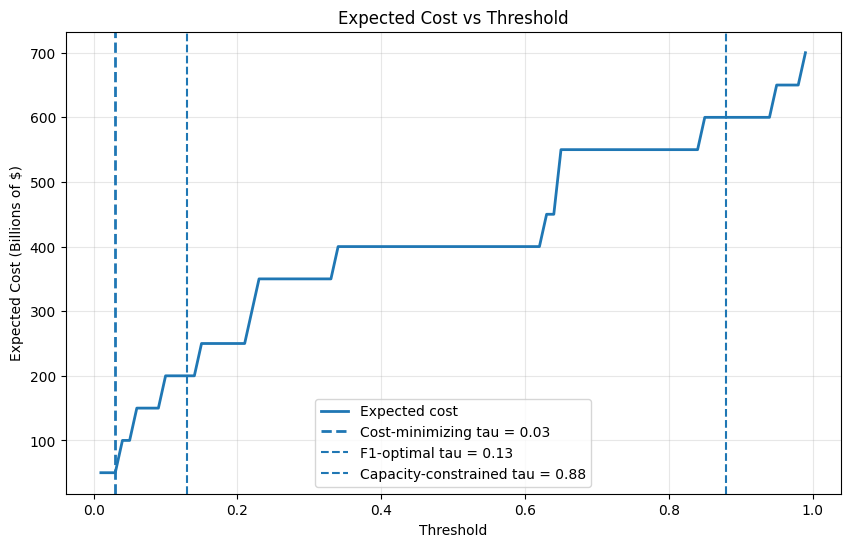

In [33]:
# =========================================================
# TASK 4.2: Cost-Sensitive Threshold Optimization
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Cost assumptions
COST_FN = 50_000_000_000   # $50B
COST_FP = 2_000_000        # $2M

thresholds = np.arange(0.01, 1.00, 0.01)

cost_rows = []

for t in thresholds:
    y_pred_t = (logit_pred_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_clf, y_pred_t).ravel()
    expected_cost = fn * COST_FN + fp * COST_FP

    cost_rows.append({
        "threshold": t,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "expected_cost": expected_cost
    })

cost_df = pd.DataFrame(cost_rows)

# Cost-minimizing threshold
cost_min_row = cost_df.sort_values(["expected_cost", "threshold"], ascending=[True, True]).iloc[0]

cost_min_t = cost_min_row["threshold"]
cost_min_tp = int(cost_min_row["TP"])
cost_min_fp = int(cost_min_row["FP"])
cost_min_fn = int(cost_min_row["FN"])
cost_min_tn = int(cost_min_row["TN"])
cost_min_value = cost_min_row["expected_cost"]

print("Cost-minimizing operating point")
print(f"Threshold tau: {cost_min_t:.2f}")
print(f"TP: {cost_min_tp}")
print(f"FP: {cost_min_fp}")
print(f"FN: {cost_min_fn}")
print(f"TN: {cost_min_tn}")
print(f"Expected cost: ${cost_min_value:,.0f}")
print()

# Compare with earlier thresholds if available
print("Comparison with previous thresholds")
print(f"F1-optimal threshold: {f1_t:.2f}")
print(f"Capacity-constrained threshold: {capacity_t:.2f}")
print(f"Cost-minimizing threshold: {cost_min_t:.2f}")

# Display top rows with lowest cost
print("\nLowest-cost thresholds:")
print(cost_df.sort_values("expected_cost").head(10))

# Plot expected cost curve
plt.figure(figsize=(10, 6))
plt.plot(cost_df["threshold"], cost_df["expected_cost"] / 1e9, linewidth=2, label="Expected cost")
plt.axvline(cost_min_t, linestyle="--", linewidth=2, label=f"Cost-minimizing tau = {cost_min_t:.2f}")
plt.axvline(f1_t, linestyle="--", linewidth=1.5, label=f"F1-optimal tau = {f1_t:.2f}")
plt.axvline(capacity_t, linestyle="--", linewidth=1.5, label=f"Capacity-constrained tau = {capacity_t:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Expected Cost (Billions of $)")
plt.title("Expected Cost vs Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The cost-minimizing threshold is τ = 0.03, which is much lower than both the F1-optimal threshold of 0.13 and the capacity-constrained threshold of 0.88. This happens because the cost function is extremely asymmetric: a missed crisis costs about $50 billion, while a false alarm costs only about $2 million, so the model strongly prefers lower thresholds that reduce false negatives even at the expense of many more false positives. I would recommend the cost-minimizing threshold if the objective is purely to minimize expected economic losses, but in practice the IMF may need to balance that recommendation against operational mission-capacity constraints.